---
format:
  html:
    code-fold: true
    code-summary: "Mostrar código"
---

# El balance de materia

En cualquier empresa quesera, con independencia de su tamaño, una de las primeras y más básicas cosas a realizar es un análisis del balance global de la elaboración quesera. Para un período determinado, que como primera aproximación, puede ser anual, se trata de conocer el balance entre la leche comprada y el queso producido, tanto en materia grasa como en proteína. Dado que toda la materia que no esté en el queso no puede ser vendida, no recuperaremos el coste de materia de las pérdidas (el suero de quesería ya no es un ingreso por venta; en la actualidad, en la mayor parte de los casos el suero es recogido a valor cero por las empresas que se encargan del secado de suero, con el valor del transporte como elemento de negociación).

En nuestro ejemplo, los datos que vamos a utilizar están registrados en ficheros de datos en formato `CSV`, que incluyen las entradas de leche en fábrica, los movimientos de leche dentro de la fábrica hasta su envío a fabricación, y las analíticas de la leche y el queso, así como alguna analítica adicional del proceso.

Analizaremos el conjunto de datos con `python`y Excel, siguiendo nuestra línea de trabajo.

## Caso de una fabricación sencilla de un tipo de leche

 Comenzaremos con el caso más simple, en el que se utiliza un solo tipo de leche, que no se estandariza en MG ni en MP, y se envía a fabricación después de pasteurización.

In [2]:
#| echo: false

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

url_datos = (
    "https://raw.githubusercontent.com/"
    "juanriera/master-queseria/master/"
    "datos/rutas_leche_vaca.csv"
)

try:
    df = pd.read_csv(url_datos, decimal = ",", sep=';', encoding='ISO-8859-1')
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

Verificamos los datos que hemos leído imprimiendo las primeras líneas del CSV

In [3]:
df.head()

,fecha,cod_ruta,tipo_leche,peso,temp,acidez,ph,densidad,est,mg,prot,lactosa,caseina
0,04/11/2015,13,VACA,13380,6.0,15.0,6.84,1.03,12.45,3.71,3.34,4.71,2.31
1,04/11/2015,13,VACA,8520,6.0,15.0,6.81,1.03,12.83,3.94,3.40,4.74,2.41
2,04/11/2015,22,VACA,23900,6.0,15.0,6.82,1.03,12.47,3.66,3.22,4.85,2.29
3,04/11/2015,24,VACA,14640,7.7,15.0,6.86,1.03,12.35,3.68,3.25,4.69,2.26
4,04/11/2015,24,VACA,7500,6.0,15.0,6.82,1.03,12.64,3.83,3.24,4.77,2.28


Verificamos la información del dataframe

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5028 entries, 0 to 5027
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       5028 non-null   object 
 1   cod_ruta    5028 non-null   int64  
 2   tipo_leche  5028 non-null   object 
 3   peso        5028 non-null   int64  
 4   temp        5028 non-null   float64
 5   acidez      5028 non-null   float64
 6   ph          5028 non-null   float64
 7   densidad    5028 non-null   float64
 8   est         5022 non-null   float64
 9   mg          5022 non-null   float64
 10  prot        5022 non-null   float64
 11  lactosa     5021 non-null   float64
 12  caseina     5011 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 510.8+ KB
None


In [6]:
df['densidad'].value_counts()

densidad
1.03    5028
Name: count, dtype: int64

In [7]:
# crear index con fecha
df['fecha_index'] = pd.to_datetime(
    df['fecha'], 
    format='%d/%m/%Y',  # Formato Día/Mes/Año confirmado
    errors='coerce'     # Clave: convierte los valores que no puede leer a NaT (Not a Time)
)
# 2. Limpiar NaT y establecer el índice
df.dropna(subset=['fecha_index'], inplace=True)
df.set_index('fecha_index', inplace=True)
df.sort_index(inplace=True)



En una fábrica en la que se elabora más de un producto, y se utilizan varios tipos de leche y otras materias primas, es conveniente separar en varias partes los movimientos de entrada e internos, para facilitar el análisis posterior.

 el fichero de datos de fabricación debe parecerse a éste, en el que se detallan los volúmenes y analíticas tanto de la leche enviada a fabricación como de los quesos elaborados. Caracterizaremos nuestro queso mediante un análisis de extracto seco total (EST) y una grasa butirométrica (MG), en un punto determinado de nuestro proceso (por ejemplo, a la salida de la salmuera, después de escurrido) y mediante un muestreo repetible, de forma que nuestro análisis sea representativo. A partir de estos dos análisis, calculamos otros parámetros técnicos necesarios, tales como la materia grasa sobre el extracto seco total (G/ES), el extracto seco magro o desnatado (ESM) y la humedad del queso desnatado (HQD), valores que se calculan a partir de los primeros.

In [ ]:
# Agrupar y sumar
resumen = df.groupby('receta')[['litros_past', 'peso_queso_total']].sum()

# Calcular la relación litros/kilo
resumen['litros_por_kilo'] = resumen['litros_past']/ resumen['peso_queso_total']

# Estimación del balance global
resumen['balance_kilos'] = resumen['peso_queso_total']-(resumen['litros_past']*1.030)

# Estimación del % de suero producido
resumen['suero_estimado_%'] = (resumen['balance_kilos']/1.020)/resumen['litros_past']*100

# Mostrar la tabla resultante
print(resumen)

         litros_past  peso_queso_total  litros_por_kilo  balance_kilos  \
receta                                                                   
bajo mg       133820           15005.8         8.917885     -122828.80   
i+D            59600            6763.0         8.812657      -54625.00   
mezcla        135300           21628.7         6.255577     -117730.30   
oveja         117970           21614.0         5.458036      -99895.10   
vaca          129333           15814.0         8.178386     -117398.99   

         suero_estimado_%  
receta                     
bajo mg        -89.986842  
i+D            -89.855573  
mezcla         -85.308103  
oveja          -83.018032  
vaca           -88.992793  


---

Dado que nuestros valores analíticos están expresados en porcentaje en peso, calculamos las cantidades de materia como se indica a continuación:

In [3]:
#| code-fold: false

### 1. Cálculos de Entradas
df['est_kg_cuba'] = df['kg_cuba'] * df['est_cuba'] / 100
df['mg_kg_cuba'] = df['kg_cuba'] * df['mg_cuba'] / 100
df['mp_kg_cuba'] = df['kg_cuba'] * df['mp_cuba'] / 100
df['esm_kg_cuba'] = df['est_kg_cuba'] - df['mg_kg_cuba'] 

### 2. Cálculos de Salidas
df['est_kg_queso'] = df['peso_queso_total'] * df['est_salida_salmuera'] / 100
df['mg_kg_queso'] = df['peso_queso_total'] * df['mg_salida_salmuera'] / 100
df['esm_kg_queso'] = df['est_kg_queso'] - df['mg_kg_queso']
df['sal_kg_queso'] = df['peso_queso_total'] * df['sal_queso']/100

### 3. Coeficientes de recuperación (expresado en porcentaje)
df['coef_recup_mg']  = df['mg_kg_queso']/df['mg_kg_cuba'] * 100
df['coef_recup_mp']  = df['esm_kg_queso']/df['mp_kg_cuba'] * 100 # atencion a la fórmula de cálculo, deberia ser mp_kg_queso
df['coef_recup_esm'] = df['esm_kg_queso']/df['esm_kg_cuba'] * 100

### 4. Consumos de materia por kilo de queso (expresado en gramos de materia por kilo de queso)
df['consumo_mg_kg'] = df['mg_kg_cuba'] / df['peso_queso_total'] * 1000
df['consumo_mp_kg'] = df['mp_kg_cuba'] / df['peso_queso_total'] * 1000

### 5. Balance de Materia (Salida - Entrada)
# La falta de producto queda como negativo al hacer Salida - Entrada
df['balance_est'] = df['est_kg_queso'] - df['est_kg_cuba']
df['balance_mg'] = df['mg_kg_queso'] - df['mg_kg_cuba']
df['balance_esm'] = df['esm_kg_queso'] - df['esm_kg_cuba'] - df['sal_kg_queso']


In [4]:
### 6. Preparación y Exportación del DataFrame de Resultados
# Columnas finales a incluir en el reporte
columnas_balance = [
    'fecha', 'receta', 'formato',
    'litros_past', 'peso_queso_total',
    'est_kg_cuba', 'est_kg_queso', 
    'mg_kg_cuba', 'mg_kg_queso', 'mp_kg_cuba',
    'esm_kg_cuba', 'esm_kg_queso', 
    'coef_recup_mg', 'coef_recup_mp', 'coef_recup_esm',
    'consumo_mg_kg', 'consumo_mp_kg',
    'balance_est', 'balance_mg', 'balance_esm'
]

# Crear un nuevo DataFrame con las columnas de interés
df_balance = df[columnas_balance].copy()

# Guardar el DataFrame con punto decimal y separador ';'
nombre_archivo_salida = 'datos/informe_balance_materia.csv'
df_balance.to_csv(
    nombre_archivo_salida, 
    sep=';', 
    index=False,
    decimal=','
)


Ahora vamos a crear un nuevo `csv`con el balance de materia semanal, aprovechando las funciones de `pandas`para crear una columna de semana ISO.

In [5]:
# 1. Crear la columna 'semana' usando el formato ISO (Lunes=Día 1)
# Usamos el índice del DataFrame (que debe ser DatetimeIndex)
df['semana_iso'] = df.index.strftime('%G-W%V') 

print("✅ Columna 'semana_iso' creada con el estándar Lunes-Domingo.")

✅ Columna 'semana_iso' creada con el estándar Lunes-Domingo.


In [6]:
# Columnas que queremos sumarizar (Balances + Entradas + Salidas)
columnas_a_sumarizar = [
    # Entradas
    'est_kg_cuba', 'mg_kg_cuba', 'esm_kg_cuba',
    # Salidas
    'est_kg_queso', 'mg_kg_queso', 'esm_kg_queso',
    # Balances
    'balance_est', 'balance_mg', 'balance_esm'
]

# 2. Agrupar por 'semana_iso' y 'receta' y calcular la SUMA de todas las columnas
df_balance_semanal_completo = df.groupby(['semana_iso', 'balance_mg'])[columnas_a_sumarizar].sum()

# Renombrar las columnas para indicar que son totales
df_balance_semanal_completo.columns = [f'total_{col}' for col in columnas_a_sumarizar]

In [7]:
# 1. Definir el nombre del archivo de salida
nombre_archivo_final = 'datos/reporte_balance_completo_semanal_iso.csv'

# 2. Exportar el DataFrame a CSV
df_balance_semanal_completo.to_csv(
    nombre_archivo_final, 
    sep=';',        # Usa punto y coma como separador de columnas
    index=True,     # Mantiene las columnas de agrupación ('semana_iso' y 'receta')
    decimal=','     # Usa coma como separador decimal
)

In [8]:
df_sns  = df_balance_semanal_completo.reset_index(drop=False) # False mantiene la columna index como columna normal

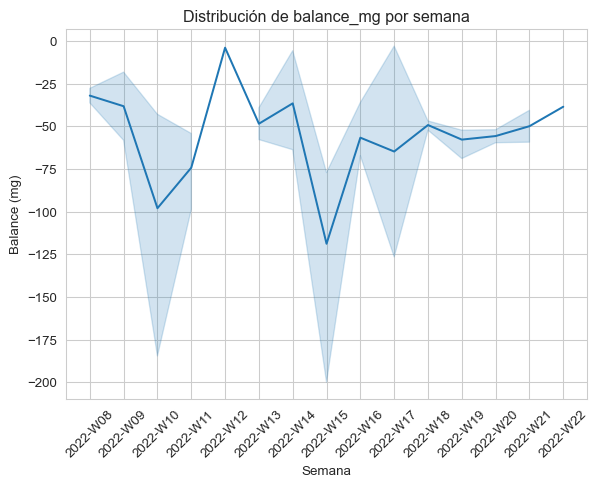

In [9]:
sns.lineplot(x='semana_iso', y='balance_mg', data=df_sns)

# Opcional: mejorar la visualización
plt.title('Distribución de balance_mg por semana')
plt.xlabel('Semana')
plt.ylabel('Balance (mg)')
plt.xticks(rotation=45)  # Si los nombres de semana son largos
plt.show()

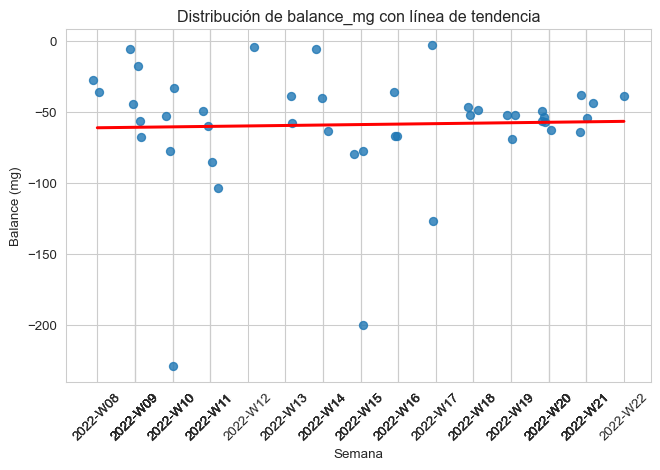

In [10]:

# Convertir semana_iso a números temporales
df_sns['semana_num'] = pd.factorize(df_sns['semana_iso'])[0]

# Dibujar la línea de tendencia con regplot
sns.regplot(
    x='semana_num',
    y='balance_mg',
    data=df_sns,
    scatter=True,
    x_jitter=0.2,     # añade jitter horizontal
    y_jitter=0.2,     # añade jitter vertical
    ci=None,
    line_kws={'color': 'red'},
)

# Reemplazar los ticks del eje X con las etiquetas originales
plt.xticks(
    ticks=df_sns['semana_num'],
    labels=df_sns['semana_iso'],
    rotation=45
)

# Mejorar visualización
plt.title('Distribución de balance_mg con línea de tendencia')
plt.xlabel('Semana')
plt.ylabel('Balance (mg)')
plt.tight_layout()
plt.show()


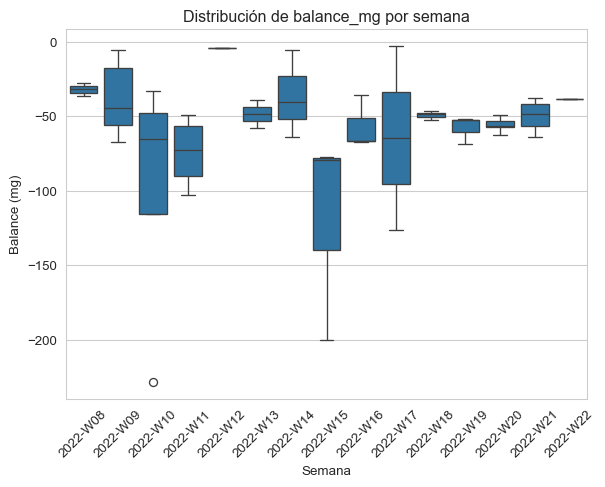

In [11]:
# Crear el boxplot
sns.boxplot(x='semana_iso', y='balance_mg', data=df_sns)

# Opcional: mejorar la visualización
plt.title('Distribución de balance_mg por semana')
plt.xlabel('Semana')
plt.ylabel('Balance (mg)')
plt.xticks(rotation=45)  # Si los nombres de semana son largos

plt.show()
